In [1]:
import json
import os
import kagglehub
import importlib
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from functools import partial

In [2]:
path = kagglehub.dataset_download("Cornell-University/arxiv")
ds_path = os.path.join(path, 'arxiv-metadata-oai-snapshot.json')

class ArxivDataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path
        self.line_offsets = []
        
        print(f"Indexing dataset at {file_path}... (this may take a minute)")
        with open(file_path, 'rb') as f:
            offset = 0
            for line in f:
                self.line_offsets.append(offset)
                offset += len(line)
        print(f"Indexed {len(self.line_offsets)} entries.")

    def __len__(self):
        return len(self.line_offsets)

    def __getitem__(self, idx):
        # Handle slice or single index
        if torch.is_tensor(idx):
            idx = idx.tolist()

        offset = self.line_offsets[idx]
        
        with open(self.file_path, 'r', encoding='utf-8') as f:
            f.seek(offset)
            line = f.readline()
            return json.loads(line)

ds = ArxivDataset(ds_path)

Indexing dataset at C:\Users\kerem\.cache\kagglehub\datasets\Cornell-University\arxiv\versions\272\arxiv-metadata-oai-snapshot.json... (this may take a minute)
Indexed 2951540 entries.


In [3]:
from workers.arxiv_parallel_processor import ArxivParallelProcessor
processor = ArxivParallelProcessor(ds)

In [4]:
# Execute again when the tasks.py file is updated
from workers import tasks
importlib.reload(tasks)

<module 'workers.tasks' from 'C:\\projects\\personal\\python-notebooks\\interview_irisai\\workers\\tasks.py'>

In [5]:
def random_explore(ds):
    data = random.choice(ds)
    fields = data.keys()
    print(fields)
    print(json.dumps(random.choice(ds), indent=4))
    

In [106]:
random_explore(ds)

dict_keys(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'])
{
    "id": "2310.17612",
    "submitter": "Xu-Dong Dai",
    "authors": "Xu-Dong Dai, Zijian Wang, He-Ran Wang, Zhong Wang",
    "title": "Steady-state topological order",
    "comments": "33 pages, 17 figures. Joint submission with arXiv:2306.12482",
    "journal-ref": null,
    "doi": null,
    "report-no": null,
    "categories": "quant-ph cond-mat.mes-hall cond-mat.quant-gas cond-mat.str-el",
    "license": "http://arxiv.org/licenses/nonexclusive-distrib/1.0/",
    "abstract": "  We investigate a generalization of topological order from closed systems to\nopen systems, for which the steady states take the place of ground states. We\nconstruct typical lattice models with steady-state topological order, and\ncharacterize them by complementary approaches based on topological degeneracy\nof steady states, to

# Dataset Structure

### IDs
<pre>
    The IDs serve as timestamps for when the paper was published. 
    Format is YYMM.PublishOrder
    e.g. 2508.12467 -> The 12467 Published paper in Augist 2025
    
    IDs before 2007 are in the format Subject/YYMMNumber
    e.g. hep-th/0602172 -> High energy physics theory - February 2006
</pre>

### Categories
<pre>
    176 unique categories
    AVG categories per entry - 1.72
    Highly unbalanced

    Two Major categories - astro-ph (105k entries) and cond-mat(15k entries) are being split down after a given time period.
    Probably because of some update in the system through the years, that adds new sub categories to them.
</pre>

In [5]:
all_categories = processor.map(tasks.get_all_categories)

Distributing task to 20 cores...


In [6]:
from collections import Counter

def get_category_analytics(categories_list):
    total_entries = len(categories_list)
    tag_counts = Counter()
    total_tags_count = 0
    
    # Process each entry (e.g., "math.CO cs.CG")
    for entry in categories_list:
        if entry:
            tags = entry.split()
            tag_counts.update(tags)
            total_tags_count += len(tags)
    
    # Calculate Metrics
    unique_categories_names = sorted(list(tag_counts.keys()))
    nr_unique_categories = len(unique_categories_names)
    avg_categories_per_entry = total_tags_count / total_entries if total_entries > 0 else 0
    
    return {
        "nr_unique": nr_unique_categories,
        "names": unique_categories_names,
        "avg_per_entry": avg_categories_per_entry,
        "raw_counts": tag_counts, # Useful for top-N analysis later
        "total_tags_count": total_tags_count
    }

analytics = get_category_analytics(all_categories)

print(f"Number of Unique Categories: {analytics['nr_unique']}")
print(f"AVG Categories per Entry:    {analytics['avg_per_entry']:.2f}")
print(f"Total count:    {analytics['total_tags_count']}")

Number of Unique Categories: 176
AVG Categories per Entry:    1.72
Total count:    5088376


In [7]:
def plot_category_distribution(category_counts, top_n=30):
    # 1. Sort and slice the top N categories
    sorted_counts = category_counts.most_common(top_n)
    names, counts = zip(*sorted_counts)
    
    # 2. Setup the plot style
    fig_height = max(6, len(category_counts) * 0.25)
    plt.figure(figsize=(12, fig_height))
    sns.set_theme(style="whitegrid")
    
    # 3. Create horizontal bar chart
    # We use a color palette to make it visually distinct
    ax = sns.barplot(
        x=list(counts), 
        y=list(names), 
        hue=list(names),    # Assign y variable to hue
        palette="viridis", 
        legend=False        # Disable the legend as it's redundant here
    )
    
    # 4. Add labels and titles
    plt.title(f"Showing {top_n} arXiv Categories by Paper Count", fontsize=16, pad=20)
    plt.xlabel("Number of Papers", fontsize=12)
    plt.ylabel("Category Tag", fontsize=12)
    
    # 5. Add value labels to the end of each bar for precision
    for i, count in enumerate(counts):
        ax.text(count + (max(counts) * 0.01), i, f'{count:,}', 
                va='center', fontsize=10, color='black')
    
    plt.tight_layout()
    plt.show()

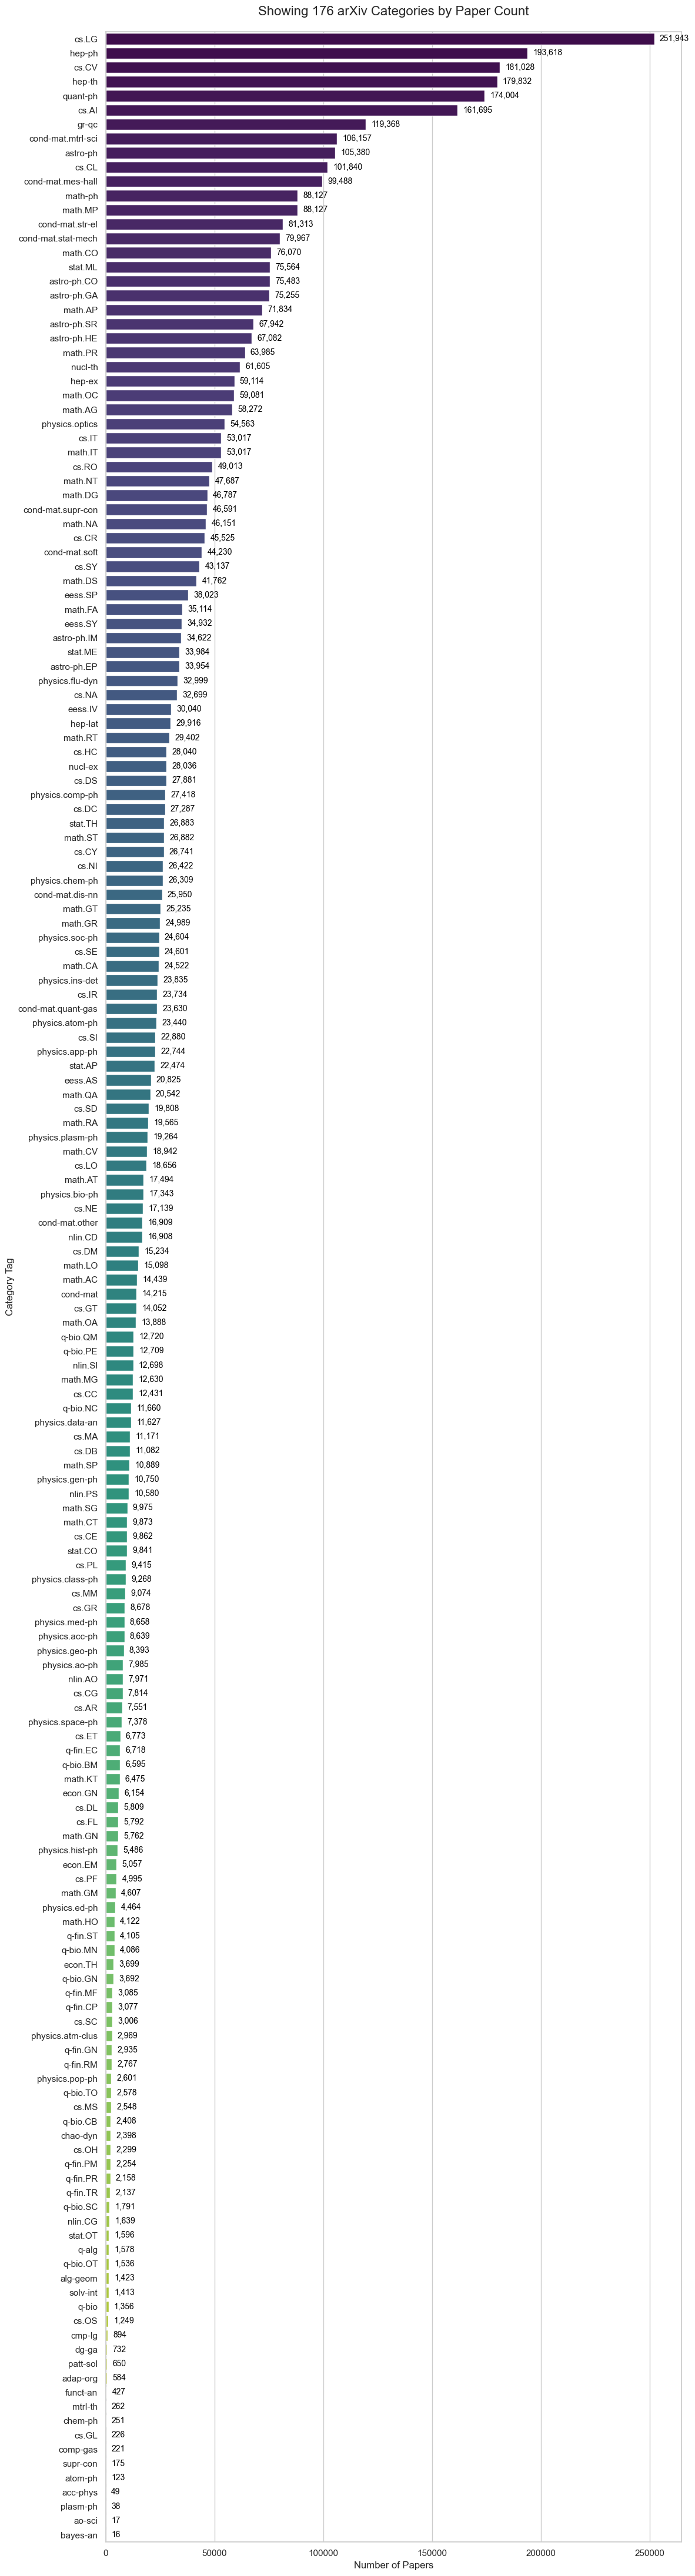

In [18]:
plot_category_distribution(analytics['raw_counts'], top_n=analytics['nr_unique'])

### Taxonomy
<pre>
    The code below fetches the taxonomy data from Arxiv.org
    It's used for comparison between the dataset categories, and the officialy listed categories in arxiv.
    Some missmatches are found (e.g. 176 classes in the dataset vs 156 from the site)
</pre>

In [8]:
import requests
from bs4 import BeautifulSoup
import json

def scrape_arxiv_taxonomy():
    url = "https://arxiv.org/category_taxonomy"
    res = requests.get(url)
    soup = BeautifulSoup(res.content, 'html.parser')
    
    taxonomy = {}
    
    # arXiv groups categories inside h4 tags (shorthand) 
    # and span tags (full name)
    categories = soup.find_all('h4')
    for cat in categories:
        # Extract shorthand (e.g., cs.LG)
        text = cat.get_text()
        if '(' in text and ')' in text:
            shorthand = text.split('(')[0].strip()
            full_name = text.split('(')[1].replace(')', '').strip()
            taxonomy[shorthand] = full_name
            
    return taxonomy

In [9]:
arxiv_taxonomy = scrape_arxiv_taxonomy()
del(arxiv_taxonomy['Category Name']) # Noise header, comming from bad scraping

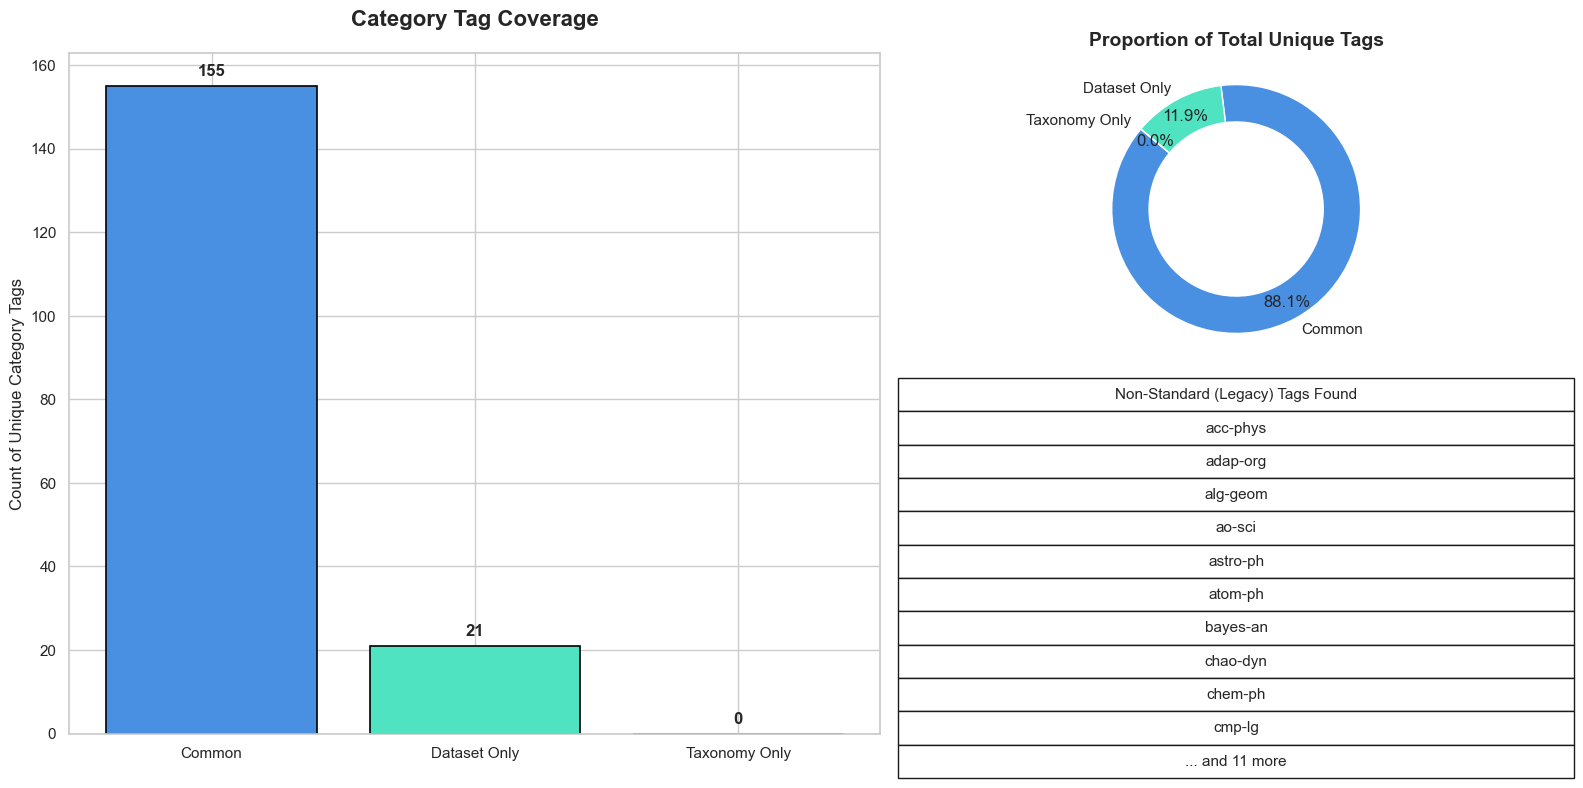

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

def compare_taxonomy_to_dataset(arxiv_taxonomy, dataset_counts):
    """
    Performs a set-theoretic comparison between official taxonomy and dataset tags.
    """
    taxonomy_set = set(arxiv_taxonomy.keys())
    dataset_set = set(dataset_counts.keys())
    
    intersection_set = taxonomy_set.intersection(dataset_set)
    taxonomy_only = taxonomy_set - dataset_set
    dataset_only = dataset_set - taxonomy_set
    
    return {
        "intersection": sorted(list(intersection_set)),
        "taxonomy_only": sorted(list(taxonomy_only)),
        "dataset_only": sorted(list(dataset_only)),
        "counts": {
            "Common": len(intersection_set),
            "Dataset Only": len(dataset_only),
            "Taxonomy Only": len(taxonomy_only)
        }
    }

def visualize_comparison(report):
    """
    Generates a dashboard showing the coverage and specific discrepancies.
    """
    # Initialize the dashboard
    fig = plt.figure(figsize=(16, 8))
    gs = plt.GridSpec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 1])
    
    # Colors: Professional Blue (Intersection), Teal (Taxonomy Only), Red (Dataset Only)
    colors = ['#4A90E2', '#50E3C2', '#D0021B']
    labels = list(report['counts'].keys())
    values = list(report['counts'].values())

    # 1. Bar Chart: Comparative Counts
    ax1 = fig.add_subplot(gs[:, 0])
    bars = ax1.bar(labels, values, color=colors, edgecolor='black', linewidth=1.2)
    ax1.set_title("Category Tag Coverage", fontsize=16, pad=20, fontweight='bold')
    ax1.set_ylabel("Count of Unique Category Tags", fontsize=12)
    
    # Adding data labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    # 2. Donut Chart: Proportional Breakdown
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, 
            colors=colors, pctdistance=0.85, wedgeprops=dict(width=0.3, edgecolor='w'))
    ax2.set_title("Proportion of Total Unique Tags", fontsize=14, fontweight='bold')

    # 3. Table: Highlighting "Dataset Only" Tags
    # These are critical for data cleaning as they represent legacy or non-standard tags
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')
    
    legacy_tags = report['dataset_only']
    display_list = [[tag] for tag in legacy_tags[:10]]
    if len(legacy_tags) > 10:
        display_list.append([f"... and {len(legacy_tags)-10} more"])

    table = ax3.table(cellText=display_list if display_list else [["None Found"]], 
                      colLabels=["Non-Standard (Legacy) Tags Found"], 
                      loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8)
    
    plt.tight_layout()
    plt.show()

# Execution
comparison_report = compare_taxonomy_to_dataset(arxiv_taxonomy, analytics['raw_counts'])
visualize_comparison(comparison_report)

In [15]:
dataset_unique_counts = Counter({
    tag: analytics['raw_counts'][tag] 
    for tag in comparison_report['dataset_only']
})

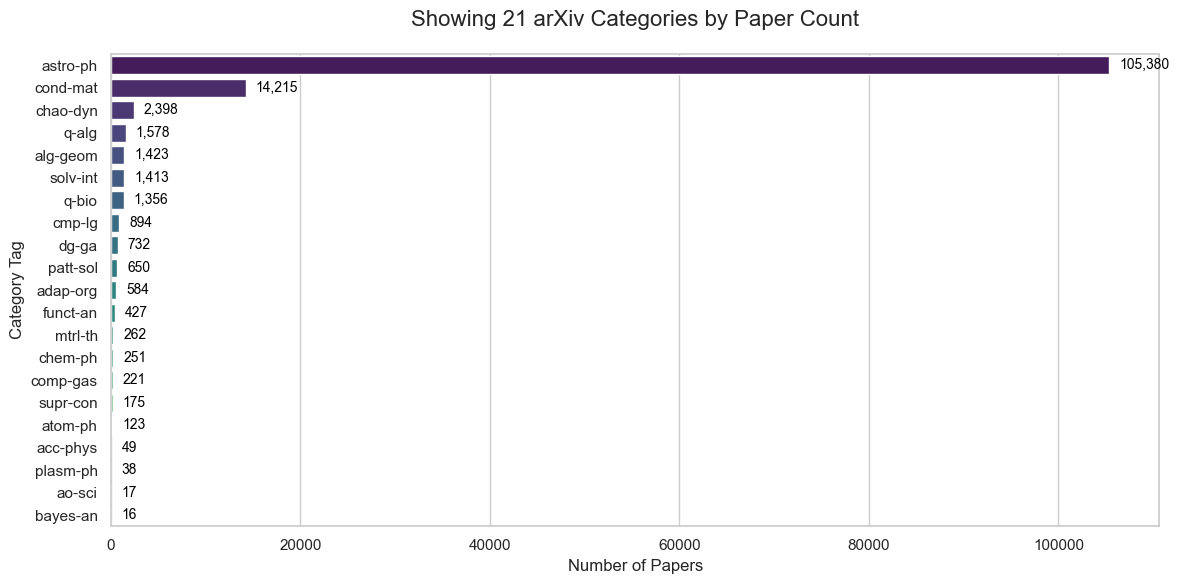

In [19]:
plot_category_distribution(dataset_unique_counts, top_n=len(dataset_unique_counts))

In [40]:
def get_date_from_id(arxiv_id):
    """
    Extracts Year and Month from both old (adap-org/9306004) 
    and new (0704.0001) arXiv IDs.
    """
    # Find the first sequence of digits
    match = re.search(r'(\d{4})', arxiv_id.split('/')[-1])
    if match:
        date_str = match.group(1) # e.g., '9306'
        year_short = int(date_str[:2])
        month = int(date_str[2:])
        
        # arXiv started in 1991. 
        # If YY > 90, it's 1900s; otherwise 2000s.
        year = 1900 + year_short if year_short > 90 else 2000 + year_short
        
        # Return as a pandas Period for easy plotting
        return pd.Period(year=year, month=month, freq='M')
    return None

In [47]:
def plot_publication_growth(dates_list, title):
    # 1. Convert list to Series and count occurrences
    date_series = pd.Series(dates_list).dropna()
    
    # Group by Year for a cleaner bar chart
    yearly_counts = date_series.apply(lambda x: x.year).value_counts().sort_index()
    
    # 2. Setup Plot
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    # 3. Create Barplot
    ax = sns.barplot(x=yearly_counts.index, y=yearly_counts.values, 
                     hue=yearly_counts.index, palette="magma", legend=False)
    
    # 4. Styling
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Number of Papers", fontsize=12)
    plt.xticks(rotation=45)
    
    # Add trend line
    plt.plot(range(len(yearly_counts)), yearly_counts.values, 
             color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [ ]:
cond_mat_papers = processor.map(partial(tasks.filter_by_category, category='cond-mat', exact=True))

Distributing task to 20 cores...


In [13]:
astro_ph_papers = processor.map(partial(tasks.filter_by_category, category='astro-ph', exact=True))

Distributing task to 20 cores...


In [51]:
cond_mat_dates = [get_date_from_id(p['id']) for p in cond_mat_papers]
astro_ph_dates = [get_date_from_id(p['id']) for p in astro_ph_papers]

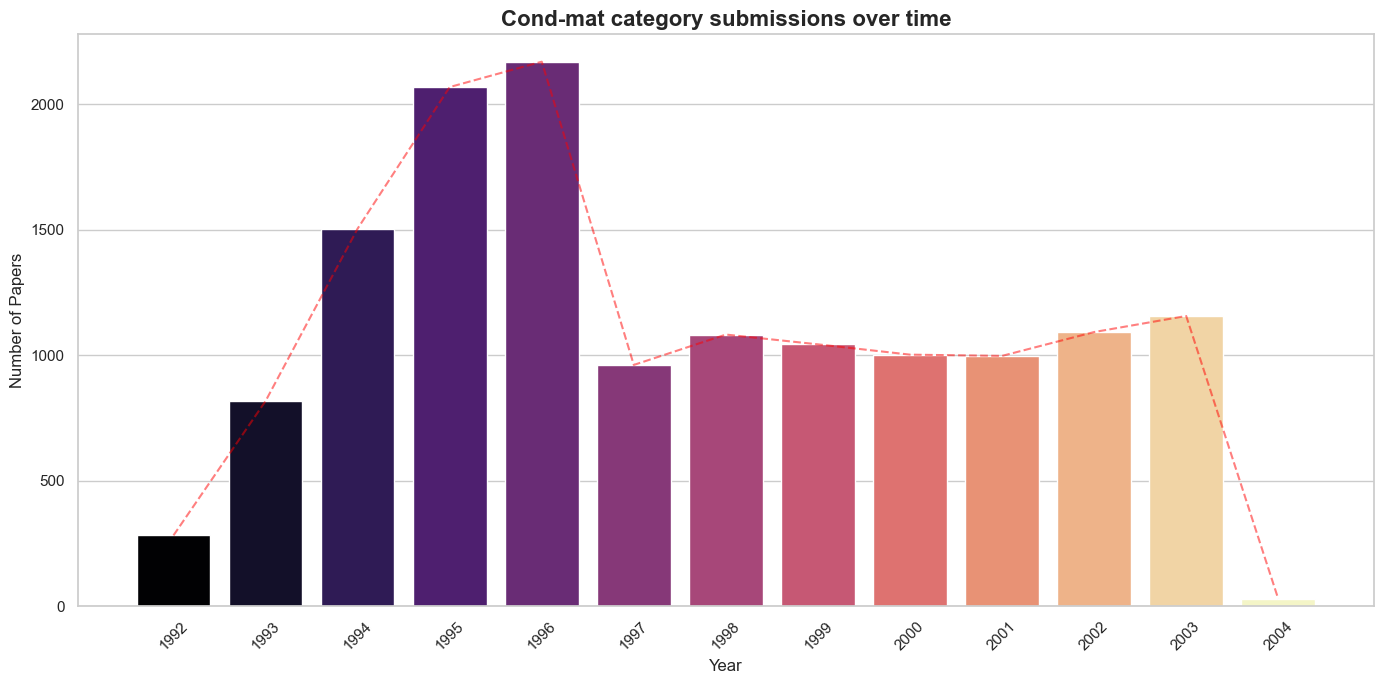

In [49]:
plot_publication_growth(cond_mat_dates, "Cond-mat category submissions over time")

In [53]:
all_astro_ph_papers = processor.map(partial(tasks.filter_by_category, category='astro-ph', exact=False))

Distributing task to 20 cores...


In [55]:
astro_ph_papers_ids = [p['id'] for p in astro_ph_papers]

In [56]:
sub_astro_ph_papers = [p for p in all_astro_ph_papers if p['id'] not in astro_ph_papers_ids]

KeyboardInterrupt: 

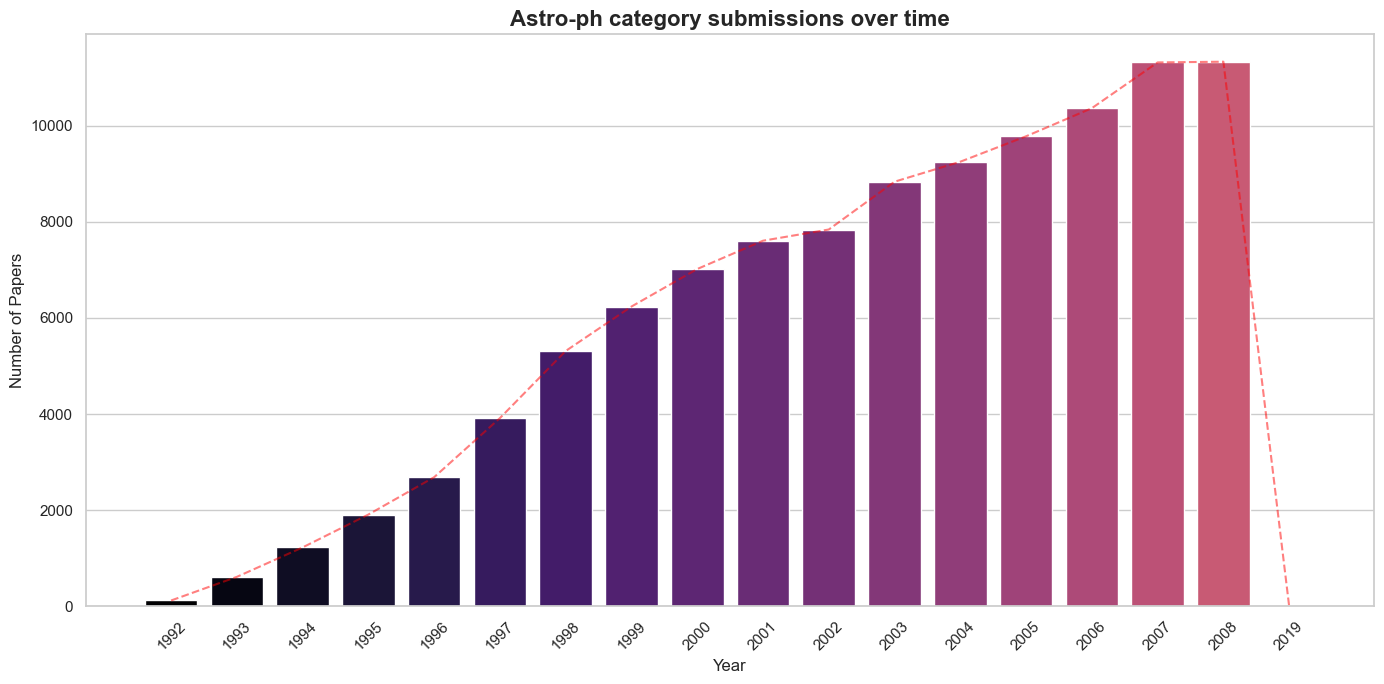

In [52]:
plot_publication_growth(astro_ph_dates, "Astro-ph category submissions over time")

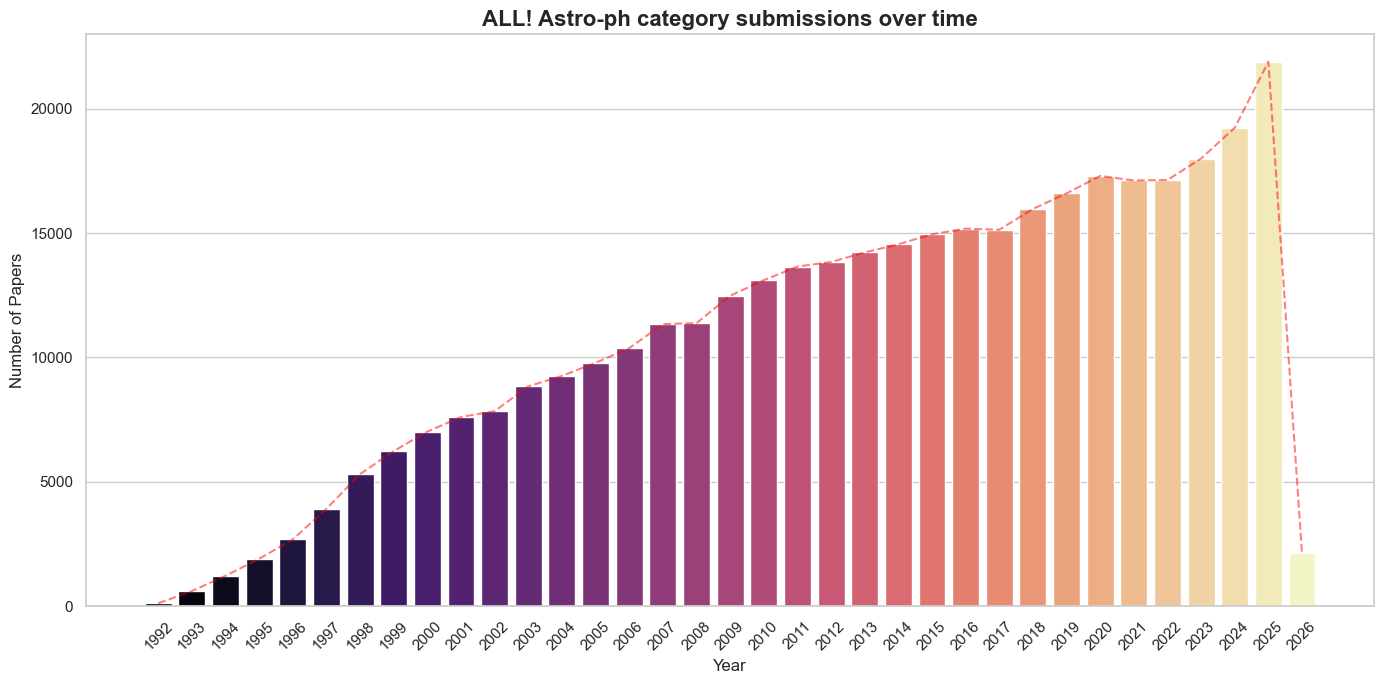

In [54]:
plot_publication_growth([get_date_from_id(p['id']) for p in all_astro_ph_papers], "ALL! Astro-ph category submissions over time")